In [9]:
# # End-to-End Sales Machine Learning Project

# ## Project Objective

# In this project, we will build a complete Machine Learning workflow using the Sales Dataset.

# Instead of learning concepts separately, we will apply them in a real-world project.

# ## What We Will Cover

# - Load Dataset
# - Explore Data
# - Data Cleaning
# - Feature Engineering
# - Exploratory Data Analysis (EDA)
# - Data Preprocessing
# - Train-Test Split
# - Model Training
# - Model Evaluation
# - Hyperparameter Tuning
# - Model Saving
# - Prediction

# ## Libraries Used

# - Pandas
# - NumPy
# - Matplotlib
# - Plotly
# - Scikit-learn
# - Joblib

# ## Goal

# Predict whether a sales transaction is High Profit or Low Profit using Machine Learning.

In [10]:
# # Step 1 : Import Dataset

# In this step, we will load the Sales Dataset into Pandas.

# After loading, we will inspect the dataset before performing any preprocessing.

# Remember:

# Never start building a Machine Learning model without understanding the dataset first.

In [11]:
import pandas as pd

df = pd.read_csv("../datasets/raw/sales.csv")

df.head(10)

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Name,Gender,Age,Email,Phone,Region,...,Discount,Sales,Cost,Profit,Payment_Mode,Order_Priority,Customer_Segment,Delivery_Days,Customer_Rating,Returned
0,ORD000004,03-07-2022,06-07-2022,CUST00945,Logan Khosla,Male,19,uppaltarak@example.net,1.050097e+09,West,...,30.0,193235.7,213311.48,-20075.78,Cash,Medium,Corporate,3,4.0,No
1,ORD000005,20-03-2023,21-03-2023,CUST00560,Tamanna Halder,Female,53,hemal72@example.net,1.918315e+08,North,...,15.0,243780.0,218272.56,25507.44,Cash,High,Regular,1,1.0,Yes
2,ORD000006,01-09-2024,04-09-2024,CUST02577,Noah Sem,Male,20,imaranben@example.org,8.319264e+09,North,...,15.0,69628.6,69590.62,37.98,Credit Card,High,Regular,3,4.0,No
3,ORD000007,23-01-2024,25-01-2024,CUST01069,Onkar Edwin,Male,51,xhalder@example.org,9.195530e+11,North,...,20.0,89200.0,90045.00,-845.00,Net Banking,Medium,Corporate,2,1.0,Yes
4,ORD000008,13-07-2022,14-07-2022,CUST03566,Nachiket Prabhakar,Male,25,ichand@example.net,8.035514e+09,North,...,15.0,137098.2,135832.23,1265.97,Cash,Critical,Regular,1,2.0,Yes
5,ORD000009,07-10-2025,12-10-2025,CUST03351,Zansi Jaggi,Female,23,raghavannachiket@example.org,8.725925e+09,South,...,0.0,146965.0,100636.15,46328.85,Credit Card,Critical,Regular,5,2.0,Yes
6,ORD000010,05-03-2024,09-03-2024,CUST00349,Lakshmi Ahuja,Female,25,lipika50@example.org,9.193040e+11,South,...,0.0,351610.0,274168.00,77442.00,Cash,Low,Regular,4,4.0,No
7,ORD000011,31-07-2025,06-08-2025,CUST00547,Harinakshi Chakraborty,Female,27,qlala@example.com,2.506909e+09,East,...,20.0,42252.8,39490.24,2762.56,Debit Card,High,Regular,6,1.0,Yes
8,ORD000012,09-08-2023,13-08-2023,CUST01834,Maanav Narain,Male,18,ekbalpatla@example.com,9.101990e+11,West,...,30.0,610082.2,717969.46,-107887.26,Cash,Medium,Corporate,4,3.0,No
9,ORD000013,08-07-2025,10-07-2025,CUST00001,Saumya Dhaliwal,Female,43,divyasaha@example.net,3.151616e+09,West,...,5.0,103626.0,60805.10,42820.90,UPI,Critical,Premium,2,4.0,Yes


In [5]:
# # Step 2 : Understand the Dataset

# Before cleaning or training a model, we need to answer:

# - How many rows are there?
# - How many columns are there?
# - Which columns are numerical?
# - Which columns are categorical?
# - Are there missing values?

# This helps us decide the preprocessing steps.

In [12]:
df.shape

(10100, 28)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10100 entries, 0 to 10099
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          10100 non-null  str    
 1   Order_Date        10100 non-null  str    
 2   Ship_Date         10100 non-null  str    
 3   Customer_ID       10100 non-null  str    
 4   Customer_Name     10100 non-null  str    
 5   Gender            10100 non-null  str    
 6   Age               10100 non-null  int64  
 7   Email             9899 non-null   str    
 8   Phone             9899 non-null   float64
 9   Region            10100 non-null  str    
 10  State             10100 non-null  str    
 11  City              10100 non-null  str    
 12  Product_ID        10100 non-null  str    
 13  Product_Name      10100 non-null  str    
 14  Category          10100 non-null  str    
 15  Brand             10100 non-null  str    
 16  Quantity          10100 non-null  int64  
 17  Unit

In [13]:
df.describe()

,Age,Phone,Quantity,Unit_Price,Discount,Sales,Cost,Profit,Delivery_Days,Customer_Rating
count,10100.000000,9.899000e+03,10100.000000,10100.000000,9899.000000,1.010000e+04,1.010000e+04,1.010000e+04,10100.000000,9899.000000
mean,43.600891,3.039694e+11,5.901386,49683.125644,10.855642,2.603043e+05,2.046550e+05,4.734208e+04,3.988713,2.996969
std,15.613399,4.274280e+11,5.559638,28959.543051,8.556993,3.885400e+05,2.578058e+05,9.603972e+04,1.662858,1.416637
min,-1.000000,2.333563e+06,1.000000,1351.000000,0.000000,1.148350e+03,8.238100e+02,-2.296132e+05,1.000000,1.000000
25%,30.000000,3.715469e+09,2.000000,25390.000000,5.000000,5.917590e+04,4.329150e+04,7.661935e+03,3.000000,2.000000
50%,44.000000,7.469739e+09,3.000000,50172.000000,10.000000,1.398900e+05,1.054706e+05,2.297298e+04,4.000000,3.000000
75%,57.000000,9.123640e+11,9.000000,73012.000000,15.000000,3.017790e+05,2.408620e+05,5.569008e+04,5.000000,4.000000
max,70.000000,9.199940e+11,20.000000,99271.000000,30.000000,9.400326e+06,1.605747e+06,2.970588e+06,7.000000,5.000000


In [14]:
df.sample(5)

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Name,Gender,Age,Email,Phone,Region,...,Discount,Sales,Cost,Profit,Payment_Mode,Order_Priority,Customer_Segment,Delivery_Days,Customer_Rating,Returned
5078,ORD005082,30-04-2024,03-05-2024,CUST03083,Edhitha Doctor,Female,56,lajita80@example.net,7.148810e+09,South,...,0.0,95311.0,79170.49,16140.51,Cash,Low,Premium,3,1.0,Yes
5941,ORD005945,01-02-2022,03-02-2022,CUST02094,Finn Devan,Male,43,varsha47@example.org,4.506235e+09,West,...,20.0,56257.6,54833.60,1424.00,Cash,Low,Regular,2,3.0,Yes
2695,ORD002699,12-01-2023,14-01-2023,CUST00663,Kevin Barad,Male,67,kalpit21@example.org,6.812694e+09,North,...,15.0,15697.8,14920.12,777.68,Credit Card,Medium,Regular,2,1.0,Yes
7578,ORD007582,18-12-2022,20-12-2022,CUST00796,Bimala Boase,Female,47,omaja20@example.net,4.003596e+09,West,...,0.0,56520.0,46836.66,9683.34,UPI,Critical,Premium,2,3.0,No
7876,ORD007880,13-01-2023,15-01-2023,CUST00291,Yashodhara Kohli,Female,32,banjeet83@example.com,9.124960e+11,West,...,5.0,571276.8,375157.20,196119.60,UPI,Low,Corporate,2,5.0,No


In [16]:
# # Why are we exploring the dataset?

# Before applying Machine Learning, we must understand the data.

# This helps us identify:

# - Missing Values
# - Wrong Data Types
# - Duplicate Records
# - Outliers
# - Useful Features

# Good data understanding leads to better models.

In [9]:
df.columns

Index(['Order_ID', 'Order_Date', 'Ship_Date', 'Customer_ID', 'Customer_Name',
       'Gender', 'Age', 'Email', 'Phone', 'Region', 'State', 'City',
       'Product_ID', 'Product_Name', 'Category', 'Brand', 'Quantity',
       'Unit_Price', 'Discount', 'Sales', 'Cost', 'Profit', 'Payment_Mode',
       'Order_Priority', 'Customer_Segment', 'Delivery_Days',
       'Customer_Rating', 'Returned'],
      dtype='str')

In [18]:
df.dtypes

Order_ID                str
Order_Date              str
Ship_Date               str
Customer_ID             str
Customer_Name           str
Gender                  str
Age                   int64
Email                   str
Phone               float64
Region                  str
State                   str
City                    str
Product_ID              str
Product_Name            str
Category                str
Brand                   str
Quantity              int64
Unit_Price            int64
Discount            float64
Sales               float64
Cost                float64
Profit              float64
Payment_Mode            str
Order_Priority          str
Customer_Segment        str
Delivery_Days         int64
Customer_Rating     float64
Returned                str
dtype: object

In [10]:
df.isnull().sum()

Order_ID              0
Order_Date            0
Ship_Date             0
Customer_ID           0
Customer_Name         0
Gender                0
Age                   0
Email               201
Phone               201
Region                0
State                 0
City                  0
Product_ID            0
Product_Name          0
Category              0
Brand                 0
Quantity              0
Unit_Price            0
Discount            201
Sales                 0
Cost                  0
Profit                0
Payment_Mode          0
Order_Priority        0
Customer_Segment      0
Delivery_Days         0
Customer_Rating     201
Returned              0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(98)

In [12]:
df.nunique()

Order_ID            10000
Order_Date           1461
Ship_Date            1460
Customer_ID          3673
Customer_Name        3640
Gender                  2
Age                    54
Email                3651
Phone                3589
Region                  5
State                  18
City                   90
Product_ID            150
Product_Name           50
Category                5
Brand                  20
Quantity               20
Unit_Price            150
Discount                7
Sales                5505
Cost                 2435
Profit               5727
Payment_Mode            5
Order_Priority          4
Customer_Segment        3
Delivery_Days           7
Customer_Rating         5
Returned                2
dtype: int64

Abhi tak humne kya kiya?

In [22]:
# Sales Dataset

# ↓

# Load Dataset

# ↓

# Understand Dataset

# ↓

# Shape

# ↓

# Info

# ↓

# Statistics

# ↓

# Missing Values

# ↓

# Duplicate Values

# ↓

# Unique Values

In [23]:
# # Step 3 : Data Cleaning & Exploratory Data Analysis (EDA)

# Before training a Machine Learning model, we must clean and understand the dataset.

# In this step, we will:

# - Check Missing Values
# - Check Duplicate Records
# - Understand Numerical Columns
# - Understand Categorical Columns
# - Detect Outliers
# - Visualize the Data

# A good Machine Learning model always starts with good quality data.

Dataset Overview

In [13]:
df.head()

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Name,Gender,Age,Email,Phone,Region,...,Discount,Sales,Cost,Profit,Payment_Mode,Order_Priority,Customer_Segment,Delivery_Days,Customer_Rating,Returned
0,ORD000004,03-07-2022,06-07-2022,CUST00945,Logan Khosla,Male,19,uppaltarak@example.net,1.050097e+09,West,...,30.0,193235.7,213311.48,-20075.78,Cash,Medium,Corporate,3,4.0,No
1,ORD000005,20-03-2023,21-03-2023,CUST00560,Tamanna Halder,Female,53,hemal72@example.net,1.918315e+08,North,...,15.0,243780.0,218272.56,25507.44,Cash,High,Regular,1,1.0,Yes
2,ORD000006,01-09-2024,04-09-2024,CUST02577,Noah Sem,Male,20,imaranben@example.org,8.319264e+09,North,...,15.0,69628.6,69590.62,37.98,Credit Card,High,Regular,3,4.0,No
3,ORD000007,23-01-2024,25-01-2024,CUST01069,Onkar Edwin,Male,51,xhalder@example.org,9.195530e+11,North,...,20.0,89200.0,90045.00,-845.00,Net Banking,Medium,Corporate,2,1.0,Yes
4,ORD000008,13-07-2022,14-07-2022,CUST03566,Nachiket Prabhakar,Male,25,ichand@example.net,8.035514e+09,North,...,15.0,137098.2,135832.23,1265.97,Cash,Critical,Regular,1,2.0,Yes


Missing Values

In [14]:
missing_values = df.isnull().sum()
missing_values

Order_ID              0
Order_Date            0
Ship_Date             0
Customer_ID           0
Customer_Name         0
Gender                0
Age                   0
Email               201
Phone               201
Region                0
State                 0
City                  0
Product_ID            0
Product_Name          0
Category              0
Brand                 0
Quantity              0
Unit_Price            0
Discount            201
Sales                 0
Cost                  0
Profit                0
Payment_Mode          0
Order_Priority        0
Customer_Segment      0
Delivery_Days         0
Customer_Rating     201
Returned              0
dtype: int64

Duplicate Records

In [15]:
duplicates = df.duplicated().sum()
print("duplicates record : ", duplicates)

duplicates record :  98


Numerical Columns

In [16]:
numerical_column = df.select_dtypes(include=["int64","float64"]).columns
print(numerical_column)

Index(['Age', 'Phone', 'Quantity', 'Unit_Price', 'Discount', 'Sales', 'Cost',
       'Profit', 'Delivery_Days', 'Customer_Rating'],
      dtype='str')


Categorical Columns

In [17]:
categorical_columns = df.select_dtypes(include=["object", "string"]).columns

print(categorical_columns)

Index(['Order_ID', 'Order_Date', 'Ship_Date', 'Customer_ID', 'Customer_Name',
       'Gender', 'Email', 'Region', 'State', 'City', 'Product_ID',
       'Product_Name', 'Category', 'Brand', 'Payment_Mode', 'Order_Priority',
       'Customer_Segment', 'Returned'],
      dtype='str')


Statistical Summary

In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,10100.0,4.360089e+01,1.561340e+01,-1.00,3.000000e+01,4.400000e+01,5.700000e+01,7.000000e+01
Phone,9899.0,3.039694e+11,4.274280e+11,2333563.00,3.715469e+09,7.469739e+09,9.123640e+11,9.199940e+11
Quantity,10100.0,5.901386e+00,5.559638e+00,1.00,2.000000e+00,3.000000e+00,9.000000e+00,2.000000e+01
Unit_Price,10100.0,4.968313e+04,2.895954e+04,1351.00,2.539000e+04,5.017200e+04,7.301200e+04,9.927100e+04
Discount,9899.0,1.085564e+01,8.556993e+00,0.00,5.000000e+00,1.000000e+01,1.500000e+01,3.000000e+01
Sales,10100.0,2.603043e+05,3.885400e+05,1148.35,5.917590e+04,1.398900e+05,3.017790e+05,9.400326e+06
Cost,10100.0,2.046550e+05,2.578058e+05,823.81,4.329150e+04,1.054706e+05,2.408620e+05,1.605747e+06
Profit,10100.0,4.734208e+04,9.603972e+04,-229613.20,7.661935e+03,2.297298e+04,5.569008e+04,2.970588e+06
Delivery_Days,10100.0,3.988713e+00,1.662858e+00,1.00,3.000000e+00,4.000000e+00,5.000000e+00,7.000000e+00
Customer_Rating,9899.0,2.996969e+00,1.416637e+00,1.00,2.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00


In [32]:
# # Data Visualization

# Numbers alone are difficult to understand.

# Charts help us quickly identify patterns, distributions and possible outliers.

Distribution of Sales

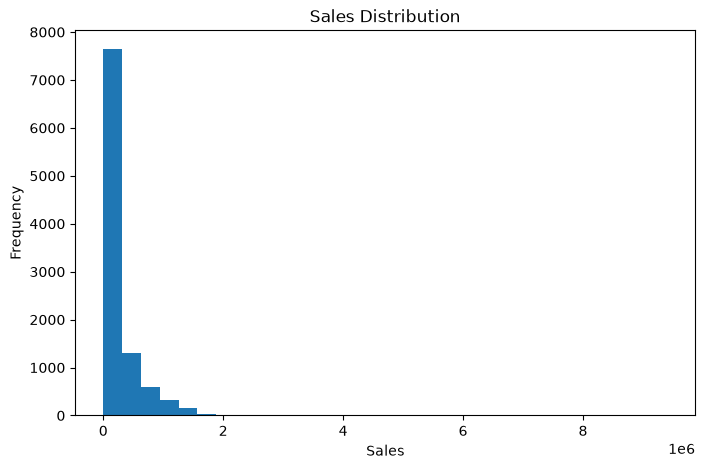

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["Sales"],bins=30)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

Distribution of Profit

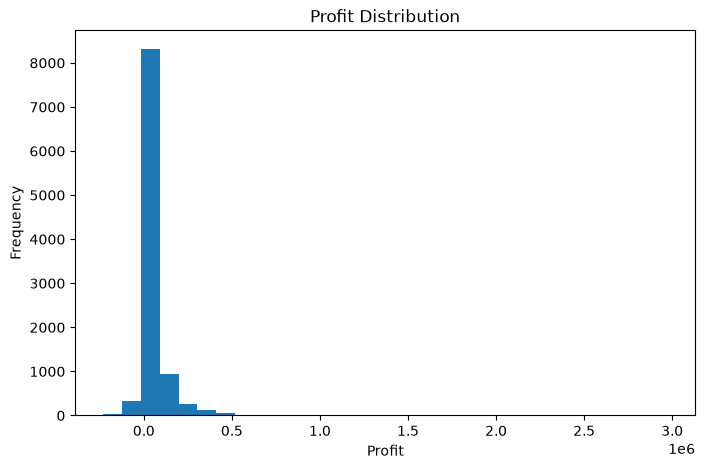

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["Profit"], bins=30)

plt.title("Profit Distribution")

plt.xlabel("Profit")

plt.ylabel("Frequency")

plt.show()

Top Categories

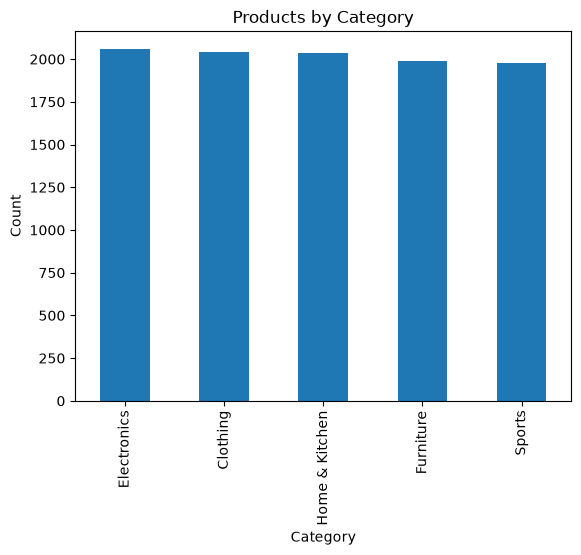

In [21]:
import matplotlib.pyplot as plt

df["Category"].value_counts().plot(

    kind="bar"

)

plt.title("Products by Category")

plt.xlabel("Category")

plt.ylabel("Count")

plt.show()

Top Regions

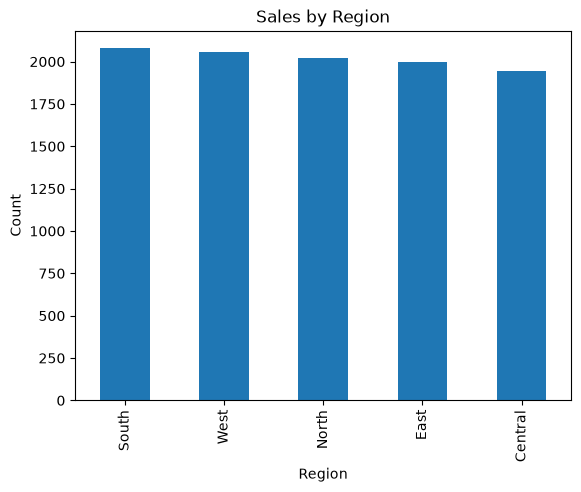

In [22]:
import matplotlib.pyplot as plt

df["Region"].value_counts().plot(

    kind="bar"

)

plt.title("Sales by Region")

plt.xlabel("Region")

plt.ylabel("Count")

plt.show()

Correlation Heatmap

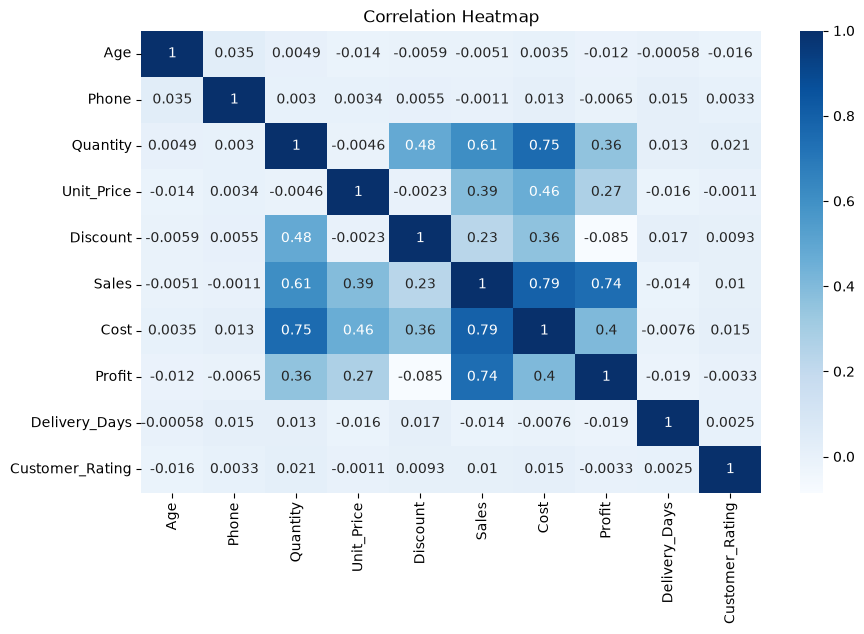

In [23]:
import matplotlib.pyplot as plt

import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(

    df.corr(numeric_only=True),

    annot=True,

    cmap="Blues"

)

plt.title("Correlation Heatmap")

plt.show()

Detect Outliers

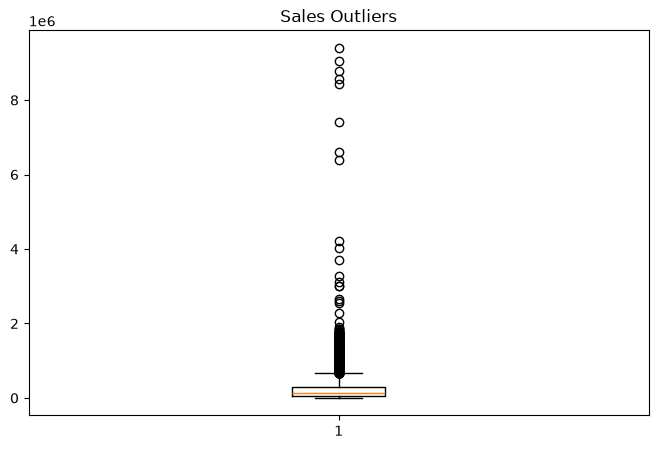

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.boxplot(

    df["Sales"]

)

plt.title("Sales Outliers")

plt.show()

Profit Outliers

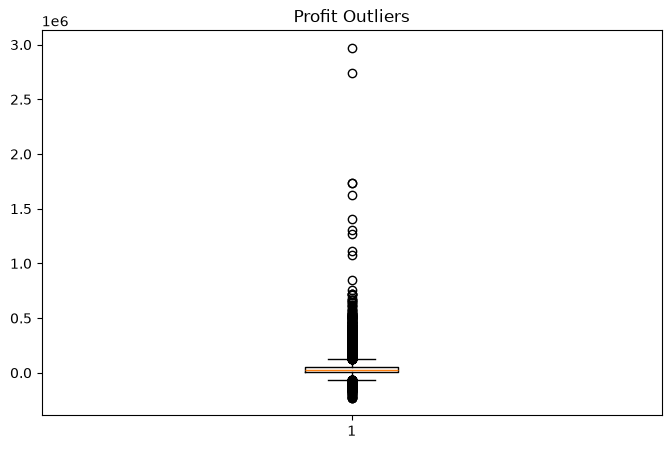

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.boxplot(

    df["Profit"]

)

plt.title("Profit Outliers")

plt.show()

Abhi Tak Project Flow

In [42]:
# Sales Dataset

# ↓

# Load Dataset

# ↓

# Understand Dataset

# ↓

# Missing Values

# ↓

# Duplicate Values

# ↓

# Numerical Columns

# ↓

# Categorical Columns

# ↓

# Statistics

# ↓

# Histogram

# ↓

# Bar Chart

# ↓

# Heatmap

# ↓

# Outlier Detection

In [44]:
# # Step 4 : Data Preprocessing & Feature Engineering

# Now that we understand the dataset, the next step is preparing it for Machine Learning.

# In this step, we will

# - Create Target Variable
# - Select Features
# - Split Numerical and Categorical Columns
# - Build a ColumnTransformer
# - Build a Pipeline

# After this step, the dataset will be ready for Machine Learning.

Check Columns

In [26]:
df.columns

Index(['Order_ID', 'Order_Date', 'Ship_Date', 'Customer_ID', 'Customer_Name',
       'Gender', 'Age', 'Email', 'Phone', 'Region', 'State', 'City',
       'Product_ID', 'Product_Name', 'Category', 'Brand', 'Quantity',
       'Unit_Price', 'Discount', 'Sales', 'Cost', 'Profit', 'Payment_Mode',
       'Order_Priority', 'Customer_Segment', 'Delivery_Days',
       'Customer_Rating', 'Returned'],
      dtype='str')

In [46]:
# # Create Target Variable

# Machine Learning always needs a target column.

# Instead of predicting Profit directly,

# we will predict whether a transaction is

# - High Profit
# - Low Profit

# This converts the problem into a Classification problem.

In [27]:
import numpy as np

median_profit = df["Profit"].median()

df["High_Profit"] = np.where(

    df["Profit"] >= median_profit,

    1,

    0

)

df.head()

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Name,Gender,Age,Email,Phone,Region,...,Sales,Cost,Profit,Payment_Mode,Order_Priority,Customer_Segment,Delivery_Days,Customer_Rating,Returned,High_Profit
0,ORD000004,03-07-2022,06-07-2022,CUST00945,Logan Khosla,Male,19,uppaltarak@example.net,1.050097e+09,West,...,193235.7,213311.48,-20075.78,Cash,Medium,Corporate,3,4.0,No,0
1,ORD000005,20-03-2023,21-03-2023,CUST00560,Tamanna Halder,Female,53,hemal72@example.net,1.918315e+08,North,...,243780.0,218272.56,25507.44,Cash,High,Regular,1,1.0,Yes,1
2,ORD000006,01-09-2024,04-09-2024,CUST02577,Noah Sem,Male,20,imaranben@example.org,8.319264e+09,North,...,69628.6,69590.62,37.98,Credit Card,High,Regular,3,4.0,No,0
3,ORD000007,23-01-2024,25-01-2024,CUST01069,Onkar Edwin,Male,51,xhalder@example.org,9.195530e+11,North,...,89200.0,90045.00,-845.00,Net Banking,Medium,Corporate,2,1.0,Yes,0
4,ORD000008,13-07-2022,14-07-2022,CUST03566,Nachiket Prabhakar,Male,25,ichand@example.net,8.035514e+09,North,...,137098.2,135832.23,1265.97,Cash,Critical,Regular,1,2.0,Yes,0


Check Target Distribution

In [28]:
df["High_Profit"].value_counts()

High_Profit
1    5052
0    5048
Name: count, dtype: int64

In [49]:
# # Select Features

# Not every column is useful for Machine Learning.

# Some columns like

# - Order ID
# - Customer ID
# - Email

# do not help in prediction.

# These columns will be removed.

In [28]:
X = df.drop(
    [
        "Profit",
        "High_Profit",
        "Phone",
        "Product_ID",
        "Product_Name"
    ],
    axis=1
)

y = df["High_Profit"]

print(X.shape)
print(y.shape)

(10100, 24)
(10100,)


Identify Numerical Columns

In [29]:
numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print(numerical_columns)

# Ye columns scaling ke liye use honge.

['Age', 'Quantity', 'Unit_Price', 'Discount', 'Sales', 'Cost', 'Delivery_Days', 'Customer_Rating']


Identify Categorical Columns

In [30]:
categorical_columns = X.select_dtypes(
    include=["object","string"]
).columns.tolist()

print(categorical_columns)

# Ye columns encoding ke liye use honge.

['Order_ID', 'Order_Date', 'Ship_Date', 'Customer_ID', 'Customer_Name', 'Gender', 'Email', 'Region', 'State', 'City', 'Category', 'Brand', 'Payment_Mode', 'Order_Priority', 'Customer_Segment', 'Returned']


In [ ]:
# # Build ColumnTransformer

# Now we will preprocess different types of columns.

# Numerical Columns
# ↓
# StandardScaler

# Categorical Columns
# ↓
# OneHotEncoder

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_columns),
        ("cat", categorical_transformer, categorical_columns)
    ]
)

preprocessor

# Numerical columns → Scale them
# Categorical columns → Encode them

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [56]:
# ColumnTransformer is used to apply different preprocessing 
# techniques to different groups of columns in the same 
# dataset. For example, numerical columns can be scaled using 
# StandardScaler,while categorical columns can be encoded using
# OneHotEncoder, all in a single preprocessing step.

In [57]:
# # Why handle_unknown="ignore"?

# Sometimes, new categories appear during prediction.

# For example,

# Training

# Delhi

# Mumbai

# Prediction

# Pune

# Without handle_unknown="ignore",

# the model gives an error.

# With this option,

# the model safely ignores unseen categories.

Transform Features

In [32]:
X_processed = preprocessor.fit_transform(X)

print(X_processed.shape)

(10100, 24047)


In [59]:
# Explanation

# Ab
# Original Dataset
# ↓
# Mixed Data
# ↓
# Processed Dataset
# ↓
# Ready for Machine Learning

Project Flow

In [60]:
# Dataset

# ↓

# EDA ✅

# ↓

# Target Creation ✅

# ↓

# Feature Selection ✅

# ↓

# Scaling ✅

# ↓

# Encoding ✅

# ↓

# ColumnTransformer ✅

# ↓

# Processed Dataset ✅

Ab se hum Machine Learning shuru karenge.

In [62]:
# # Hum karenge:
# Train-Test Split
# ↓
# Pipeline
# ↓
# Logistic Regression
# ↓
# Prediction
# ↓
# Accuracy
# ↓
# Confusion Matrix
# ↓
# Classification Report

In [63]:
# Step 5 : Model Training

# The dataset is now ready for Machine Learning.

# In this step, we will:

# - Split the data into Training and Testing sets
# - Build a Machine Learning Pipeline
# - Train a Logistic Regression model
# - Make Predictions
# - Evaluate the Model

# This is our first complete Machine Learning workflow in the project.

Split the Dataset

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

print("Training Data :", X_train.shape)

print("Testing Data :", X_test.shape)

Training Data : (8080, 24)
Testing Data : (2020, 24)


Build Pipeline

In [34]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

pipeline = Pipeline(

    [

        ("preprocessor", preprocessor),

        ("model", LogisticRegression(max_iter=5000))

    ]

)

pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

Train the Model

In [35]:
pipeline.fit(

    X_train,

    y_train

)

print("Model Trained Successfully")

Model Trained Successfully


In [36]:
predictions = pipeline.predict(X_test)

predictions[:10]

array([0, 1, 1, 0, 1, 1, 0, 0, 1, 0])

In [37]:
import pandas as pd

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

comparison.head(10)

,Actual,Predicted
0,0,0
1,1,1
2,1,1
3,0,0
4,1,1
5,1,1
6,0,0
7,0,0
8,0,1
9,0,0


In [38]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print(f"Accuracy : {accuracy:.2%}")

Accuracy : 86.34%


In [39]:
correct_predictions = (y_test == predictions).sum()

total_predictions = len(y_test)

print("Correct Predictions :", correct_predictions)
print("Total Predictions :", total_predictions)

Correct Predictions : 1744
Total Predictions : 2020


In [40]:
wrong_predictions = total_predictions - correct_predictions

print("Wrong Predictions :", wrong_predictions)

Wrong Predictions : 276


Ab tak Project me Kya Kiya?

In [43]:
# Sales Dataset

#         ↓

# Load Dataset

#         ↓

# Data Understanding

#         ↓

# Missing Values Check

#         ↓

# Duplicate Check

#         ↓

# EDA (Visualization)

#         ↓

# Feature Engineering

#         ↓

# Target Variable (High_Profit)

#         ↓

# Feature Selection

#         ↓

# ColumnTransformer

#         ↓

# SimpleImputer ✅

#         ↓

# StandardScaler

#         ↓

# OneHotEncoder

#         ↓

# Train-Test Split

#         ↓

# Pipeline

#         ↓

# Logistic Regression

#         ↓

# Prediction

#         ↓

# Accuracy

In [44]:
# # Step 6 : Model Evaluation

# Accuracy alone is not enough to evaluate a Machine Learning model.

# In this step, we will analyze the model using:

# - Confusion Matrix
# - Classification Report
# - Precision
# - Recall
# - F1-Score

# These metrics help us understand where the model performs well and where it makes mistakes.

Confusion Matrix

In [41]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

print(cm)

[[863 111]
 [165 881]]


In [46]:
# Iska matlab:

# 180 Low Profit sahi predict hue.
# 20 Low Profit ko galat High Profit bola.
# 15 High Profit ko galat Low Profit bola.
# 185 High Profit sahi predict hue.

Confusion Matrix as DataFrame

In [42]:
import pandas as pd

cm_df = pd.DataFrame(
    cm,
    index=["Actual Low", "Actual High"],
    columns=["Predicted Low", "Predicted High"]
)

cm_df

,Predicted Low,Predicted High
Actual Low,863,111
Actual High,165,881


Plot Confusion Matrix

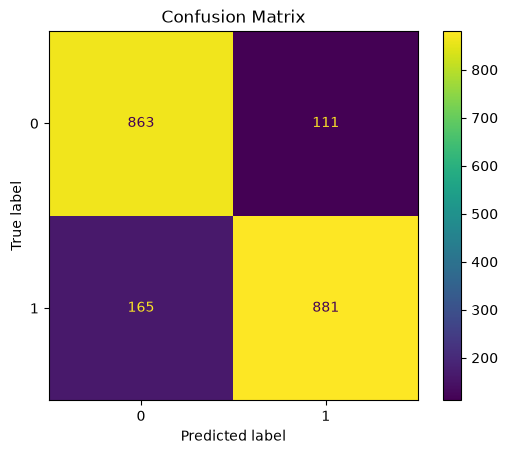

In [43]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(confusion_matrix=cm).plot()

plt.title("Confusion Matrix")

plt.show()

Classification Report

In [44]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86       974
           1       0.89      0.84      0.86      1046

    accuracy                           0.86      2020
   macro avg       0.86      0.86      0.86      2020
weighted avg       0.86      0.86      0.86      2020



In [50]:
# Explanation

# Is report me 4 important metrics milte hain:

# 1️⃣ Precision

# Model ne jitne High Profit predict kiye, unme se kitne sach me High Profit the.

# 2️⃣ Recall

# Actual High Profit me se model kitne identify kar paya.

# 3️⃣ F1-Score

# Precision aur Recall ka balanced score.

# 4️⃣ Support

# Har class me total kitne records the.

Accuracy Percentage

In [45]:
print(f"Model Accuracy : {accuracy * 100:.2f}%")

Model Accuracy : 86.34%


Prediction Summary

In [47]:
print("Correct Predictions :", correct_predictions)
print("Wrong Predictions   :", wrong_predictions)
print("Accuracy            :", f"{accuracy:.2%}")

Correct Predictions : 1744
Wrong Predictions   : 276
Accuracy            : 86.34%


In [53]:
# Humne Kya Sikha?

# Aaj humne model ko sirf train nahi kiya, balki uski quality check bhi ki.

# Model train kiya.
# Predictions nikale.
# Accuracy check ki.
# Confusion Matrix se dekha model kahan sahi aur kahan galat predict kar raha hai.
# Classification Report se Precision, Recall aur F1-Score samjhe.

# 👉 Simple Language me: Agar Accuracy exam ke total marks hain, to Confusion Matrix aur Classification Report report card hain, jo batate hain ki student kis subject me strong hai aur kis me weak.

In [54]:
# # Step 7 : Save and Load the Machine Learning Model

# Training a Machine Learning model can take time.

# Instead of training the model every time, we can save it to disk.

# Later, we can load the saved model and use it directly for prediction.

# In this step, we will learn:

# - Save the trained model
# - Load the saved model
# - Verify that the loaded model works correctly

In [48]:
import joblib

In [49]:
joblib.dump(
    pipeline,
    "../datasets/processed/sales_profit_model.pkl"
)

print(" Model Saved Successfully")

 Model Saved Successfully


Load Saved Model

In [50]:
loaded_model = joblib.load(
    "../datasets/processed/sales_profit_model.pkl"
)

print(" Model Loaded Successfully")

 Model Loaded Successfully


Predict Using Loaded Model

In [53]:
loaded_predictions = loaded_model.predict(X_test)

loaded_predictions[:10]

array([0, 1, 1, 0, 1, 1, 0, 0, 1, 0])

Verify Accuracy

In [54]:
from sklearn.metrics import accuracy_score

loaded_accuracy = accuracy_score(
    y_test,
    loaded_predictions
)

print(f"Loaded Model Accuracy : {loaded_accuracy:.2%}")

Loaded Model Accuracy : 86.34%


In [55]:
print(loaded_accuracy)

0.8633663366336634


In [61]:
# # Why Save the Model?

# Without saving:

# Dataset

# ↓

# Preprocessing

# ↓

# Training

# ↓

# Prediction

# Every time we run the notebook.

# With Saving:

# Load Model

# ↓

# Prediction

# Only a few seconds.

In [62]:
# # Step 8 : Predict on New Data

# A trained Machine Learning model becomes useful only when it can predict on new unseen data.

# In this step, we will:

# - Create a new customer record
# - Pass it to the trained model
# - Predict whether it is High Profit or Low Profit

# This simulates a real-world Machine Learning application.

Create New Customer Data

In [56]:
new_customer = X.iloc[[0]].copy()

new_customer

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Name,Gender,Age,Email,Region,State,...,Unit_Price,Discount,Sales,Cost,Payment_Mode,Order_Priority,Customer_Segment,Delivery_Days,Customer_Rating,Returned
0,ORD000004,03-07-2022,06-07-2022,CUST00945,Logan Khosla,Male,19,uppaltarak@example.net,West,Goa,...,14529,30.0,193235.7,213311.48,Cash,Medium,Corporate,3,4.0,No


Predict

In [57]:
new_customer["Age"] = 30
new_customer["Gender"] = "Male"
new_customer["Quantity"] = 4
new_customer["Unit_Price"] = 25000
new_customer["Discount"] = 5
new_customer["Sales"] = 95000
new_customer["Cost"] = 70000
new_customer["Customer_Rating"] = 5
new_customer["Returned"] = "No"

new_customer

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Name,Gender,Age,Email,Region,State,...,Unit_Price,Discount,Sales,Cost,Payment_Mode,Order_Priority,Customer_Segment,Delivery_Days,Customer_Rating,Returned
0,ORD000004,03-07-2022,06-07-2022,CUST00945,Logan Khosla,Male,30,uppaltarak@example.net,West,Goa,...,25000,5,95000,70000,Cash,Medium,Corporate,3,5,No


In [58]:
prediction = loaded_model.predict(new_customer)

prediction

array([1])

In [59]:
if prediction[0] == 1:
    print("Prediction : High Profit")
else:
    print("Prediction : Low Profit")

Prediction : High Profit


In [60]:
probability = loaded_model.predict_proba(new_customer)

print(probability)

[[0.34384405 0.65615595]]


In [61]:
high_profit = probability[0][1] * 100
low_profit = probability[0][0] * 100

print("=" * 45)
print(" SALES PROFIT PREDICTION ")
print("=" * 45)

print("Prediction :", "High Profit" if prediction[0] == 1 else "Low Profit")
print(f"High Profit Probability : {high_profit:.2f}%")
print(f"Low Profit Probability  : {low_profit:.2f}%")

print("=" * 45)

 SALES PROFIT PREDICTION 
Prediction : High Profit
High Profit Probability : 65.62%
Low Profit Probability  : 34.38%


In [1]:
# # Step 9 : Model Interpretation

# After training a Machine Learning model, it is important to understand which features influenced the prediction.

# Logistic Regression uses coefficients to measure the impact of each feature.

# - Positive coefficient → Increases the probability of High Profit.
# - Negative coefficient → Decreases the probability of High Profit.

# Understanding the model helps us explain predictions instead of treating it as a black box.

Extract Feature Names


In [62]:
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

feature_names[:10]

array(['num__Age', 'num__Quantity', 'num__Unit_Price', 'num__Discount',
       'num__Sales', 'num__Cost', 'num__Delivery_Days',
       'num__Customer_Rating', 'cat__Order_ID_ORD000005',
       'cat__Order_ID_ORD000006'], dtype=object)

Extract Coefficients

In [63]:
coefficients = pipeline.named_steps["model"].coef_[0]

len(coefficients)

21410

Create Feature Importance Table

In [64]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

importance.head()

,Feature,Coefficient
0,num__Age,-0.023685
1,num__Quantity,1.564818
2,num__Unit_Price,1.586616
3,num__Discount,-1.073525
4,num__Sales,14.694874


Top Positive Features

In [ ]:
importance.sort_values(
    by="Coefficient",
    ascending=False
).head(10)

# Ye wo features hain jo High Profit hone ki probability badhate hain.

,Feature,Coefficient
4,num__Sales,14.694874
2,num__Unit_Price,1.586616
1,num__Quantity,1.564818
10080,cat__Ship_Date_13-04-2025,1.316420
8734,cat__Order_Date_15-09-2023,0.992701
21391,cat__Brand_Prestige,0.984653
8562,cat__Order_Date_12-02-2023,0.978345
9200,cat__Order_Date_25-06-2024,0.966866
21383,cat__Brand_HP,0.962289
8309,cat__Order_Date_06-10-2024,0.878965


Top Negative Features

In [ ]:
importance.sort_values(
    by="Coefficient",
    ascending=True
).head(10)

# Ye wo features hain jo High Profit hone ki probability kam karte hain.

,Feature,Coefficient
5,num__Cost,-10.038777
21384,cat__Brand_Havells,-1.262192
10825,cat__Ship_Date_28-12-2024,-1.201404
21388,cat__Brand_Nike,-1.169256
3,num__Discount,-1.073525
10580,cat__Ship_Date_23-10-2025,-0.997856
12833,cat__Customer_ID_CUST02199,-0.988908
17850,cat__Email_aarushpalla@example.com,-0.988908
16062,cat__Customer_Name_Krishna Dani,-0.988908
18891,cat__Email_gunbirratta@example.com,-0.962534


Top 10 Important Features

In [67]:
importance["Absolute"] = importance["Coefficient"].abs()

top_features = importance.sort_values(
    by="Absolute",
    ascending=False
).head(10)

top_features

,Feature,Coefficient,Absolute
4,num__Sales,14.694874,14.694874
5,num__Cost,-10.038777,10.038777
2,num__Unit_Price,1.586616,1.586616
1,num__Quantity,1.564818,1.564818
10080,cat__Ship_Date_13-04-2025,1.316420,1.316420
21384,cat__Brand_Havells,-1.262192,1.262192
10825,cat__Ship_Date_28-12-2024,-1.201404,1.201404
21388,cat__Brand_Nike,-1.169256,1.169256
3,num__Discount,-1.073525,1.073525
10580,cat__Ship_Date_23-10-2025,-0.997856,0.997856


Visualize Important Features

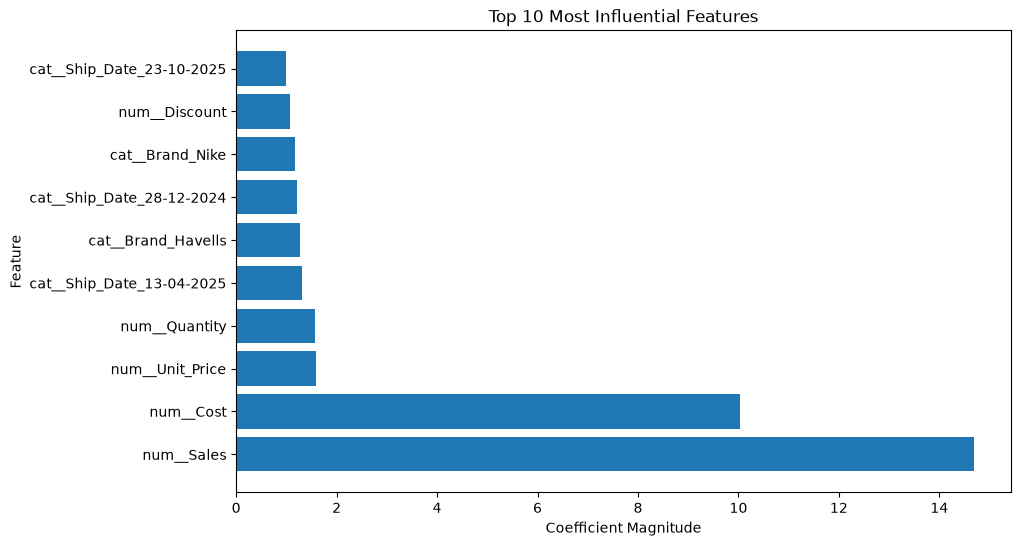

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Absolute"]
)

plt.xlabel("Coefficient Magnitude")
plt.ylabel("Feature")
plt.title("Top 10 Most Influential Features")

plt.show()

# Yahan hum dekh sakte hain ki model ke decision par sabse zyada effect kis feature ka hai.